In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [6]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from src.cnn_lstm_v2 import CNNLSTMV2
from src.XAI.gradcam import GradCAM
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_gradcam_over_rgb, plot_single_frame_gradcam
from scripts.common.get_device import get_available_device

experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_1" / "baseline"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

model = CNNLSTMV2(
    hidden_channels=hyperparameters["hidden_channels"],
    reduced_channels=hyperparameters["reduced_channels"],
    classifier_hidden_size=hyperparameters["classifier_hidden_size"],
    dropout=hyperparameters["dropout"],
    cnn_cutoff=hyperparameters["cnn_cutoff"],
    cnn_unfreeze_from=hyperparameters["cnn_unfreeze_from"]
).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

dataset = RWF2000Dataset(
    DATASET_ROOT, 
    num_frames=hyperparameters["num_frames"], 
    input_mode=hyperparameters["input_mode"], 
    augment=False, 
    split="val", 
    return_rgb_frames=True
)

Using cuda:2 with 17.92 GB free


In [7]:
video_num = 201
video, label, rbg_frames = dataset[video_num]

video_batch = video.unsqueeze(0).to(device)
# [1, 32, 3, 224, 224]
gradcam = GradCAM(model, model.cnn[-1])
cams, logits = gradcam.generate_heatmap(video_batch)

label = label.item()
prediction = torch.argmax(logits, dim=1).item()
gradcam.remove_hooks()

heatmaps = cams[0]
num_frames = heatmaps.shape[0]

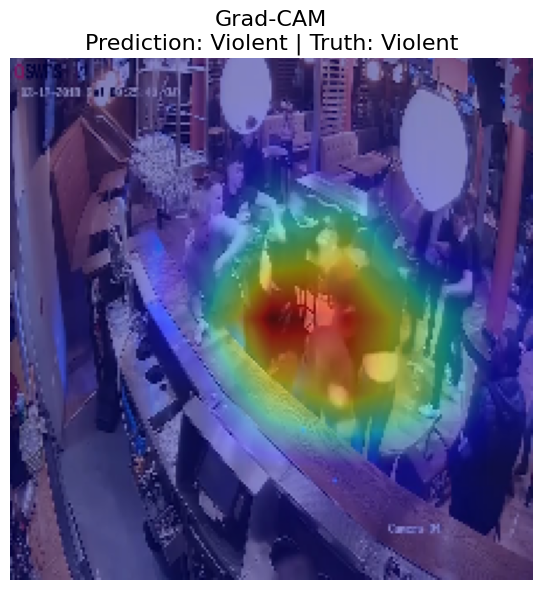

In [12]:
frame_index = 0  # Change this index to visualize different frames
plot_single_frame_gradcam(heatmaps, rbg_frames,frame_index, label, prediction, alpha=0.45)

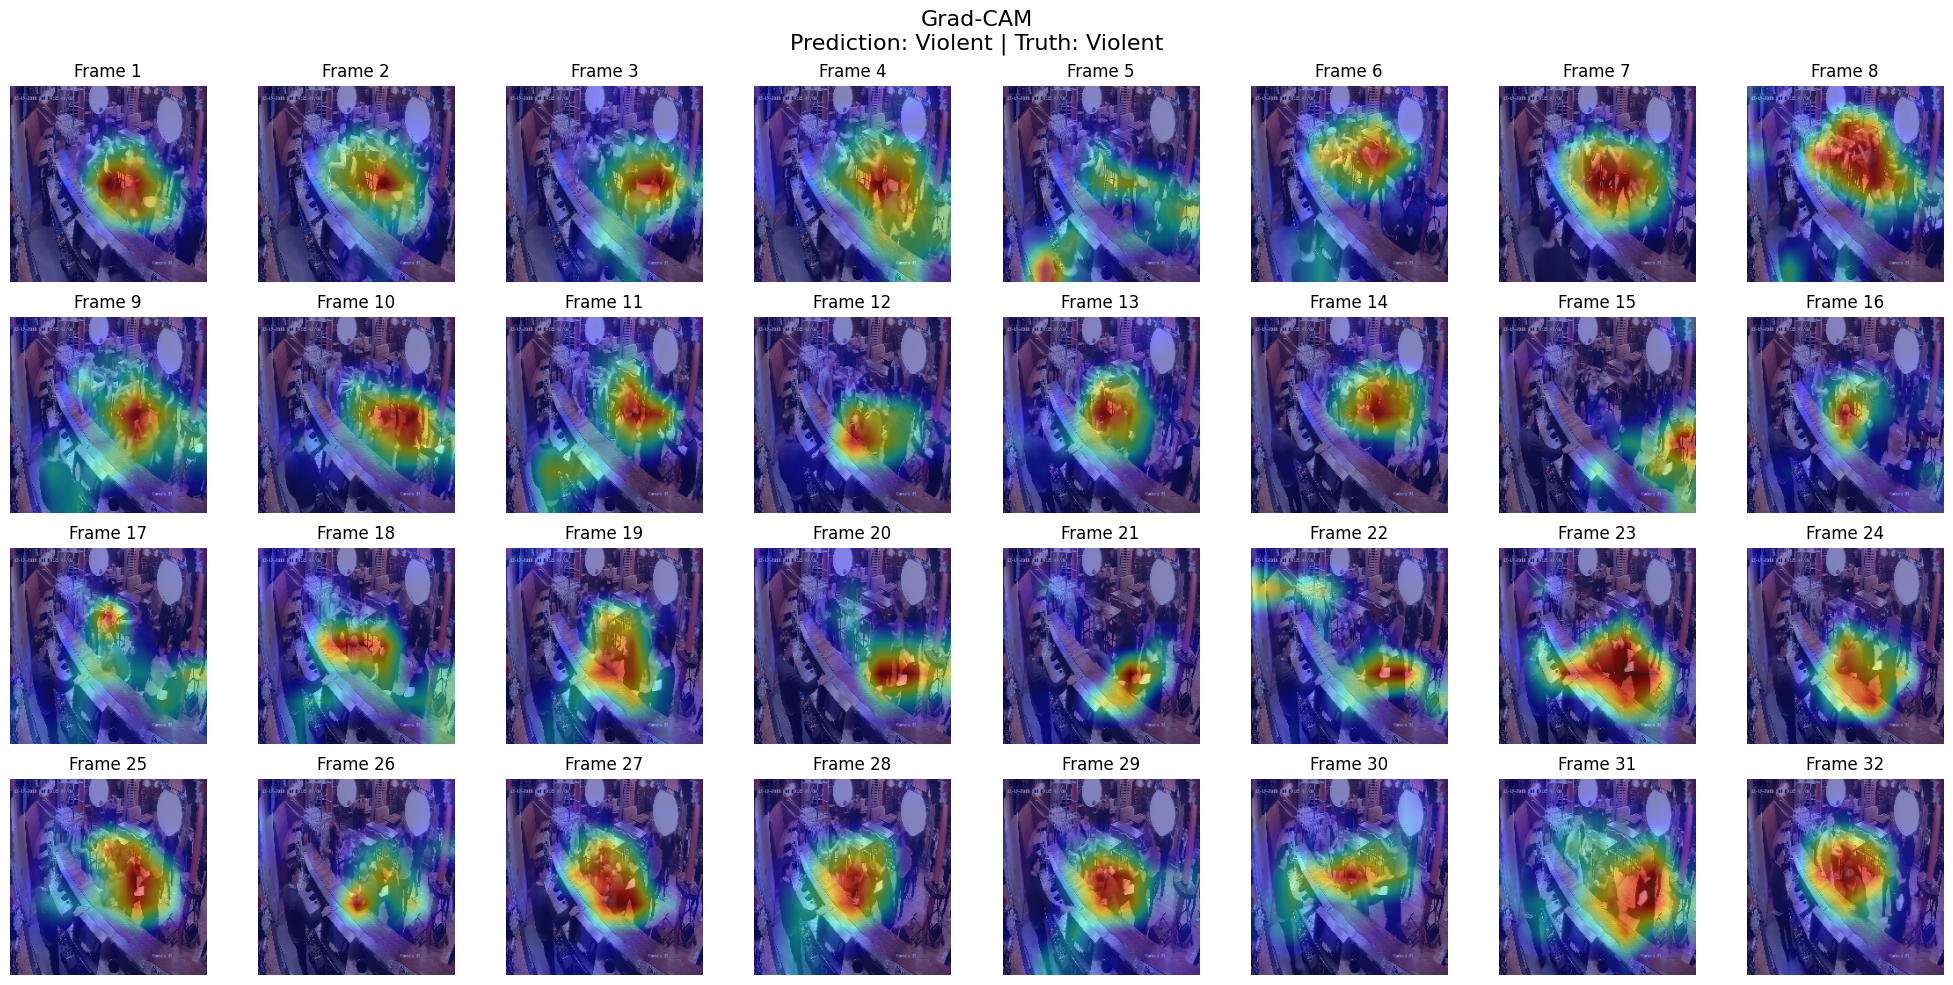

In [ ]:
plot_gradcam_over_rgb(heatmaps, rbg_frames, label, prediction, alpha=0.45)